### West Virginia

BYM and BYM-TDA 

In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt


from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve
import geopandas as gpd

# these libraries are not dependencies of pymc
import networkx as nx
import nutpie
import libpysal as ps

In [2]:
RANDOM_SEED = 8926
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
current_path = os.getcwd()

In [4]:
state_abb = "WV"
state_abb_lower = state_abb.lower()

Load the data

In [5]:
# SVI
svi_tda_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"tda_summaries_2018_{state_abb}_down.csv"), dtype={'STCNTY': str})

# SMR
smr_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"smr_data_2018_{state_abb}.csv"), dtype={'FIPS': str})

# GEO: get geometry data
geo_data = gpd.read_file(os.path.join(current_path, "data", "raw_data", "SVI2018_US_county.gdb"), dtype={"FIPS": str})

geo_data = geo_data[['FIPS', 'geometry','ST_ABBR']]

/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


In [6]:
# combine smr on FIPS and svi data on STCNTY - left
combined_data = pd.merge(smr_data, svi_tda_data, left_on="FIPS", right_on="STCNTY", how="left")

# merge combined data with geo data
combined_data = pd.merge(combined_data, geo_data, on="FIPS", how="left")

In [7]:
# print the shape
print(f"Shape of the combined data: {combined_data.shape}")

Shape of the combined data: (55, 89)


In [8]:
# get the 'state' data

combined_data = combined_data[combined_data['ST_ABBR'] == state_abb]

In [9]:
combined_data.shape

(55, 89)

In [10]:
# Adding this just to plot original data!
# Replace 0 with NaN in observed_deaths column
combined_data_map = combined_data.copy()
combined_data_map["observed_deaths"] = combined_data_map["observed_deaths"].replace(0.0, np.nan)

gdf_map = gpd.GeoDataFrame(combined_data_map, geometry='geometry')

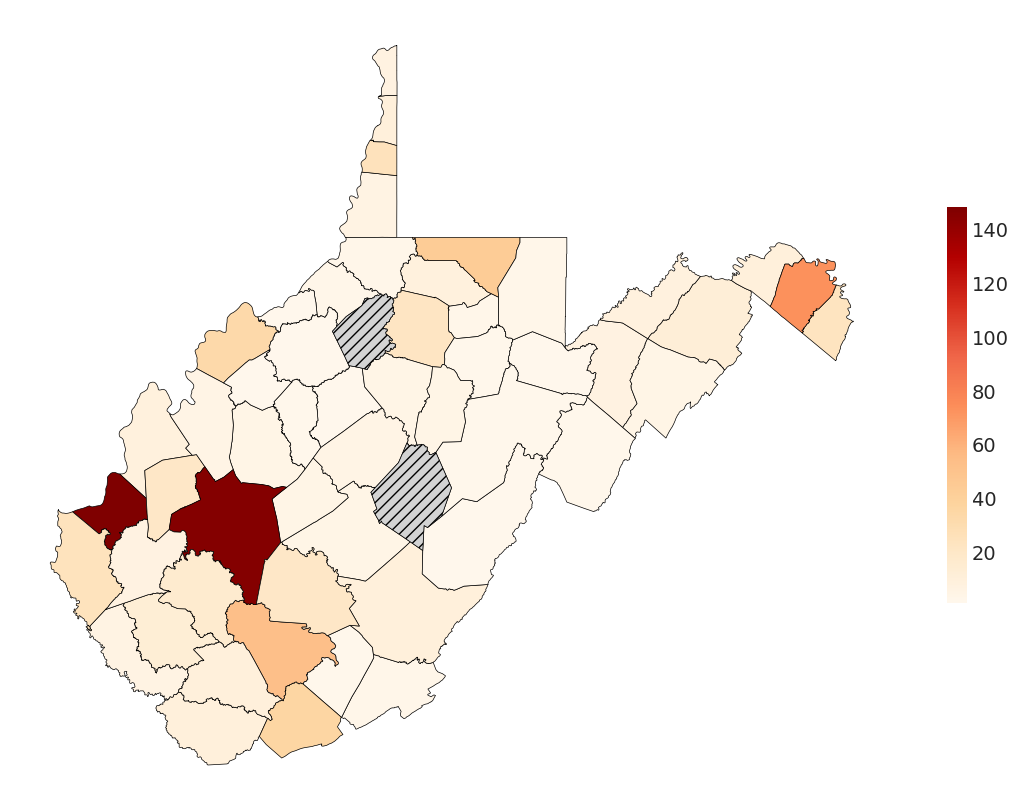

In [11]:
import matplotlib.pyplot as plt
import geopandas as gpd

# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf_map.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"observed_deaths.png"), bbox_inches='tight', dpi=300)

Cleaning the data: Removing the rows with missing observed deaths, islands, few states

In [12]:
# filter by column to have columns start with EP_ or SMR and geometry and FIPS and observed_death and expected_death
combined_data = combined_data.filter(regex='EP_|SMR|geometry|FIPS|observed_death|expected_death')

# drop the rows with observed_death = 0
combined_data = combined_data[combined_data['observed_deaths'] > 0]

# make it a geodataframe
gdf = gpd.GeoDataFrame(combined_data, geometry='geometry')

# Compute Queen adjacency
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# if we keep the islands it will cause error in the adjacency computation(empty adjacencies)
# Get the islands fips to a list
islands = w.islands

# drop the islands
combined_data = combined_data[~combined_data["FIPS"].isin(islands)]

# drop rows with FIPS starts with 72, 78, 02, 15, 60
combined_data = combined_data[~combined_data['FIPS'].str.startswith(('72', '78', '02', '15', '60'))]

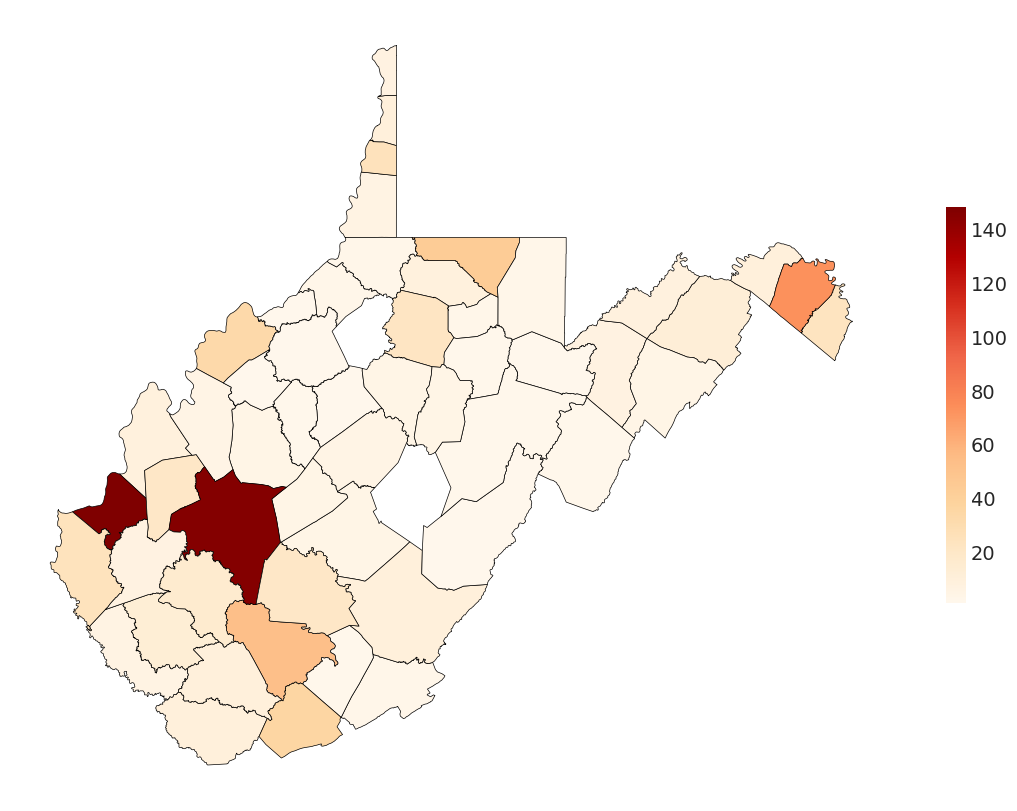

In [13]:
# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.show()

Combine TDA summaries for each state(all variables)

In [14]:
# get the column names with _AL
al_cols = combined_data.filter(regex='_AL').columns

print(f"Columns with _AL: {al_cols}")

# sum the columns with _AL
combined_data['AL'] = combined_data[al_cols].sum(axis=1)

# drop the columns with _AL
# combined_data.drop(columns=al_cols, inplace=True)

# get the column names with _TL

tl_cols = combined_data.filter(regex='_TL').columns

print(f"Columns with _TL: {tl_cols}")

# sum the columns with _TL
combined_data['TL'] = combined_data[tl_cols].sum(axis=1)

# drop the columns with _TL
# combined_data.drop(columns=tl_cols, inplace=True)

# get the column names with _AML
aml_cols = combined_data.filter(regex='_AML').columns

print(f"Columns with _AML: {aml_cols}")

# sum the columns with _AML
combined_data['AML'] = combined_data[aml_cols].sum(axis=1)

# drop the columns with _AML
# combined_data.drop(columns=aml_cols, inplace=True)

# get the column names with _TML
tml_cols = combined_data.filter(regex='_TML').columns

print(f"Columns with _TML: {tml_cols}")

# sum the columns with _TML
combined_data['TML'] = combined_data[tml_cols].sum(axis=1)

# drop the columns with _TML
# combined_data.drop(columns=tml_cols, inplace=True)

Columns with _AL: Index(['EP_POV_AL', 'EP_UNEMP_AL', 'EP_PCI_AL', 'EP_NOHSDP_AL',
       'EP_UNINSUR_AL', 'EP_AGE65_AL', 'EP_AGE17_AL', 'EP_DISABL_AL',
       'EP_SNGPNT_AL', 'EP_LIMENG_AL', 'EP_MINRTY_AL', 'EP_MUNIT_AL',
       'EP_MOBILE_AL', 'EP_CROWD_AL', 'EP_NOVEH_AL', 'EP_GROUPQ_AL'],
      dtype='object')
Columns with _TL: Index(['EP_POV_TL', 'EP_UNEMP_TL', 'EP_PCI_TL', 'EP_NOHSDP_TL',
       'EP_UNINSUR_TL', 'EP_AGE65_TL', 'EP_AGE17_TL', 'EP_DISABL_TL',
       'EP_SNGPNT_TL', 'EP_LIMENG_TL', 'EP_MINRTY_TL', 'EP_MUNIT_TL',
       'EP_MOBILE_TL', 'EP_CROWD_TL', 'EP_NOVEH_TL', 'EP_GROUPQ_TL'],
      dtype='object')
Columns with _AML: Index(['EP_POV_AML', 'EP_UNEMP_AML', 'EP_PCI_AML', 'EP_NOHSDP_AML',
       'EP_UNINSUR_AML', 'EP_AGE65_AML', 'EP_AGE17_AML', 'EP_DISABL_AML',
       'EP_SNGPNT_AML', 'EP_LIMENG_AML', 'EP_MINRTY_AML', 'EP_MUNIT_AML',
       'EP_MOBILE_AML', 'EP_CROWD_AML', 'EP_NOVEH_AML', 'EP_GROUPQ_AML'],
      dtype='object')
Columns with _TML: Index(['EP_POV_TML', '

Get the adjacency matrix

In [15]:
# create the queen adjacency matrix
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# Spatial adjacency matrix (N x N) with binary entries for neighbor relationships.
# make it into a matrix
W = w.full()[0]

In [16]:
# print the shape of W
print(f"Shape of W: {W.shape}")

Shape of W: (53, 53)


Prepare data and adjacency structures

In [17]:
y = combined_data["observed_deaths"].values
E = combined_data["expected_deaths"].values

EP_POV_AV_ORI = combined_data["EP_POV_AV_ORI"].values
EP_UNEMP_AV_ORI = combined_data["EP_UNEMP_AV_ORI"].values
EP_PCI_AV_ORI = combined_data["EP_PCI_AV_ORI"].values
EP_NOHSDP_AV_ORI = combined_data["EP_NOHSDP_AV_ORI"].values
EP_AGE65_AV_ORI = combined_data["EP_AGE65_AV_ORI"].values
EP_AGE17_AV_ORI = combined_data["EP_AGE17_AV_ORI"].values
EP_DISABL_AV_ORI = combined_data["EP_DISABL_AV_ORI"].values
EP_SNGPNT_AV_ORI = combined_data["EP_SNGPNT_AV_ORI"].values
EP_MINRTY_AV_ORI = combined_data["EP_MINRTY_AV_ORI"].values
EP_LIMENG_AV_ORI = combined_data["EP_LIMENG_AV_ORI"].values
EP_MUNIT_AV_ORI = combined_data["EP_MUNIT_AV_ORI"].values
EP_MOBILE_AV_ORI = combined_data["EP_MOBILE_AV_ORI"].values
EP_CROWD_AV_ORI = combined_data["EP_CROWD_AV_ORI"].values
EP_NOVEH_AV_ORI = combined_data["EP_NOVEH_AV_ORI"].values
EP_GROUPQ_AV_ORI = combined_data["EP_GROUPQ_AV_ORI"].values

EP_POV_AL = combined_data["EP_POV_AL"].values


# mean standerdize only EP_POV_AL 
mean_value = combined_data["EP_POV_AL"].mean()
std_value = combined_data["EP_POV_AL"].std()
combined_data["EP_POV_AL"] = (combined_data["EP_POV_AL"] - mean_value) / std_value

AL = combined_data["EP_POV_AL"].values

E[E < 10] = 10
log_E = np.log(E)

area_idx = combined_data["FIPS"].values
coords = {"area_idx": area_idx}

N = len(y)

# # THETA = df_clean["AL"].values
# theta_values = combined_data.set_index("FIPS")["AL"].to_dict()
# theta = np.array([theta_values[fips] for fips in area_idx])

Scaling Factors

In [18]:
def scaling_factor_sp(A):
    """Compute the scaling factor from an adjacency matrix.
    This function uses sparse matrix computations and is most
    efficient on sparse adjacency matrices. Used in the BYM2 model.
    The scaling factor is a measure of the variance in the number of
    edges across nodes in a connected graph.
    Only works for fully connected graphs. The argument for scaling
    factors is developed by Andrea Riebler, Sigrunn H. Sørbye,
    Daniel Simpson, Havard Rue in "An intuitive Bayesian spatial
    model for disease mapping that accounts for scaling"
    https://arxiv.org/abs/1601.01180"""

    # Computes the precision matrix in sparse format
    # from an adjacency matrix.

    num_neighbors = A.sum(axis=1)
    A = sparse.csc_matrix(A)
    D = sparse.diags(num_neighbors, format="csc")
    Q = D - A

    # add a small jitter along the diagonal

    Q_perturbed = Q + sparse.diags(np.ones(Q.shape[0])) * max(Q.diagonal()) * np.sqrt(
        np.finfo(np.float64).eps
    )

    # Compute a version of the pseudo-inverse

    n = Q_perturbed.shape[0]
    b = sparse.identity(n, format="csc")
    Sigma = spsolve(Q_perturbed, b)
    A = np.ones(n)
    W = Sigma @ A.T
    Q_inv = Sigma - np.outer(W * solve(A @ W, np.ones(1)), W.T)

    # Compute the geometric mean of the diagonal on a
    # precision matrix.

    return np.exp(np.sum(np.log(np.diag(Q_inv))) / n)


scaling_factor = scaling_factor_sp(W)
scaling_factor

0.5991931651817699

In [19]:
import pymc as pm
import arviz as az

In [20]:
coefficients = [
    "beta_pov"
]

####  I. BYM-T model 1: Uniform case D(1,1,1)

In [21]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_1:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   alpha = pm.Dirichlet("alpha", a=np.array([1.0, 1.0, 1.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

Sampling the data

In [22]:
with model_1:

    # # Sample from the model:
    trace_model_1 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 114 seconds.


R hat statistics

In [23]:
# Calculate r_hat for sigma and alpha
rhat_data_model_1 = az.rhat(trace_model_1, var_names=["sigma","alpha","beta_pov"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_1["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_1["alpha"].values}')

R-hat for sigma: 1.000597666343161
R-hat for alpha: [1.00108392 1.00063605 1.00052834]


In [24]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_1[var].values}')

R-hat for beta_pov: 1.0003942724769106


Rank plots

array([<Axes: title={'center': 'alpha\n0'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha\n1'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha\n2'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'sigma'}, xlabel='Rank (all chains)', ylabel='Chain'>],
      dtype=object)

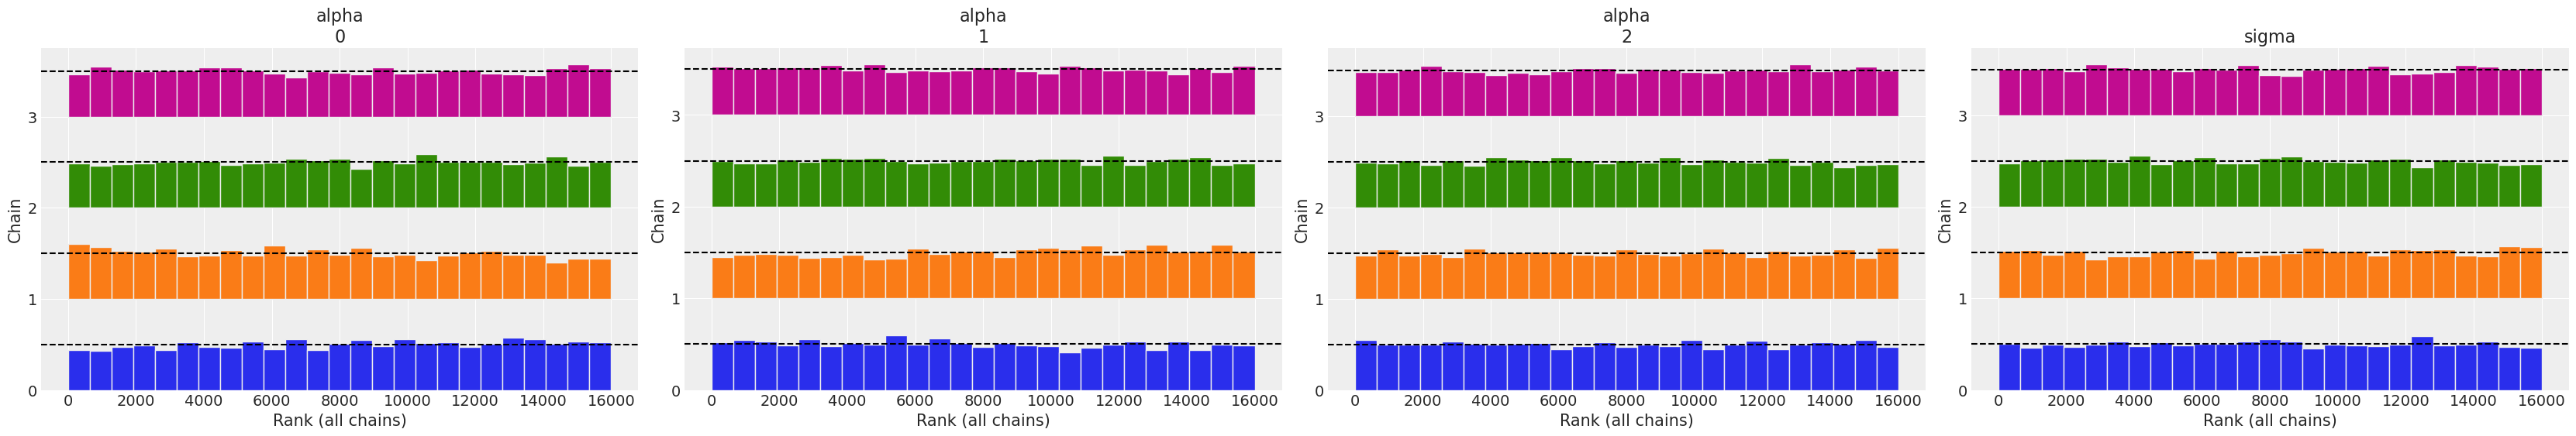

In [25]:
# Plot for specific variables (e.g., your 'phi' and 'sigma')
az.plot_rank(trace_model_1, var_names=["alpha", "sigma"])

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_95736/3653008493.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Helps prevent label overlap


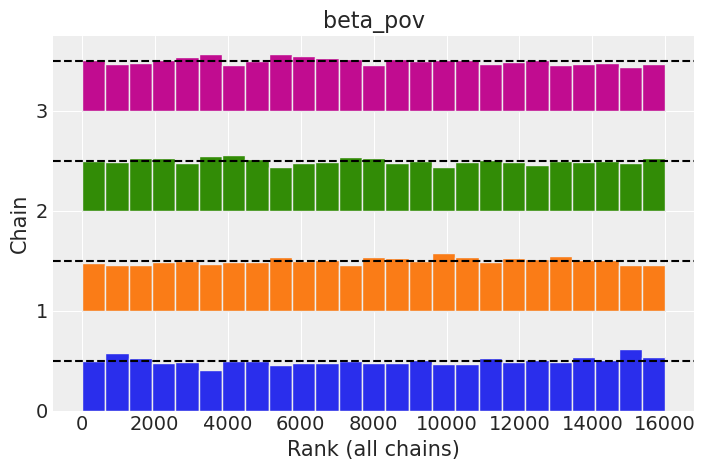

In [26]:
# plot rank plots for all coefficients

az.plot_rank(trace_model_1, var_names=coefficients)
plt.tight_layout() # Helps prevent label overlap

Checking Autocorrlation

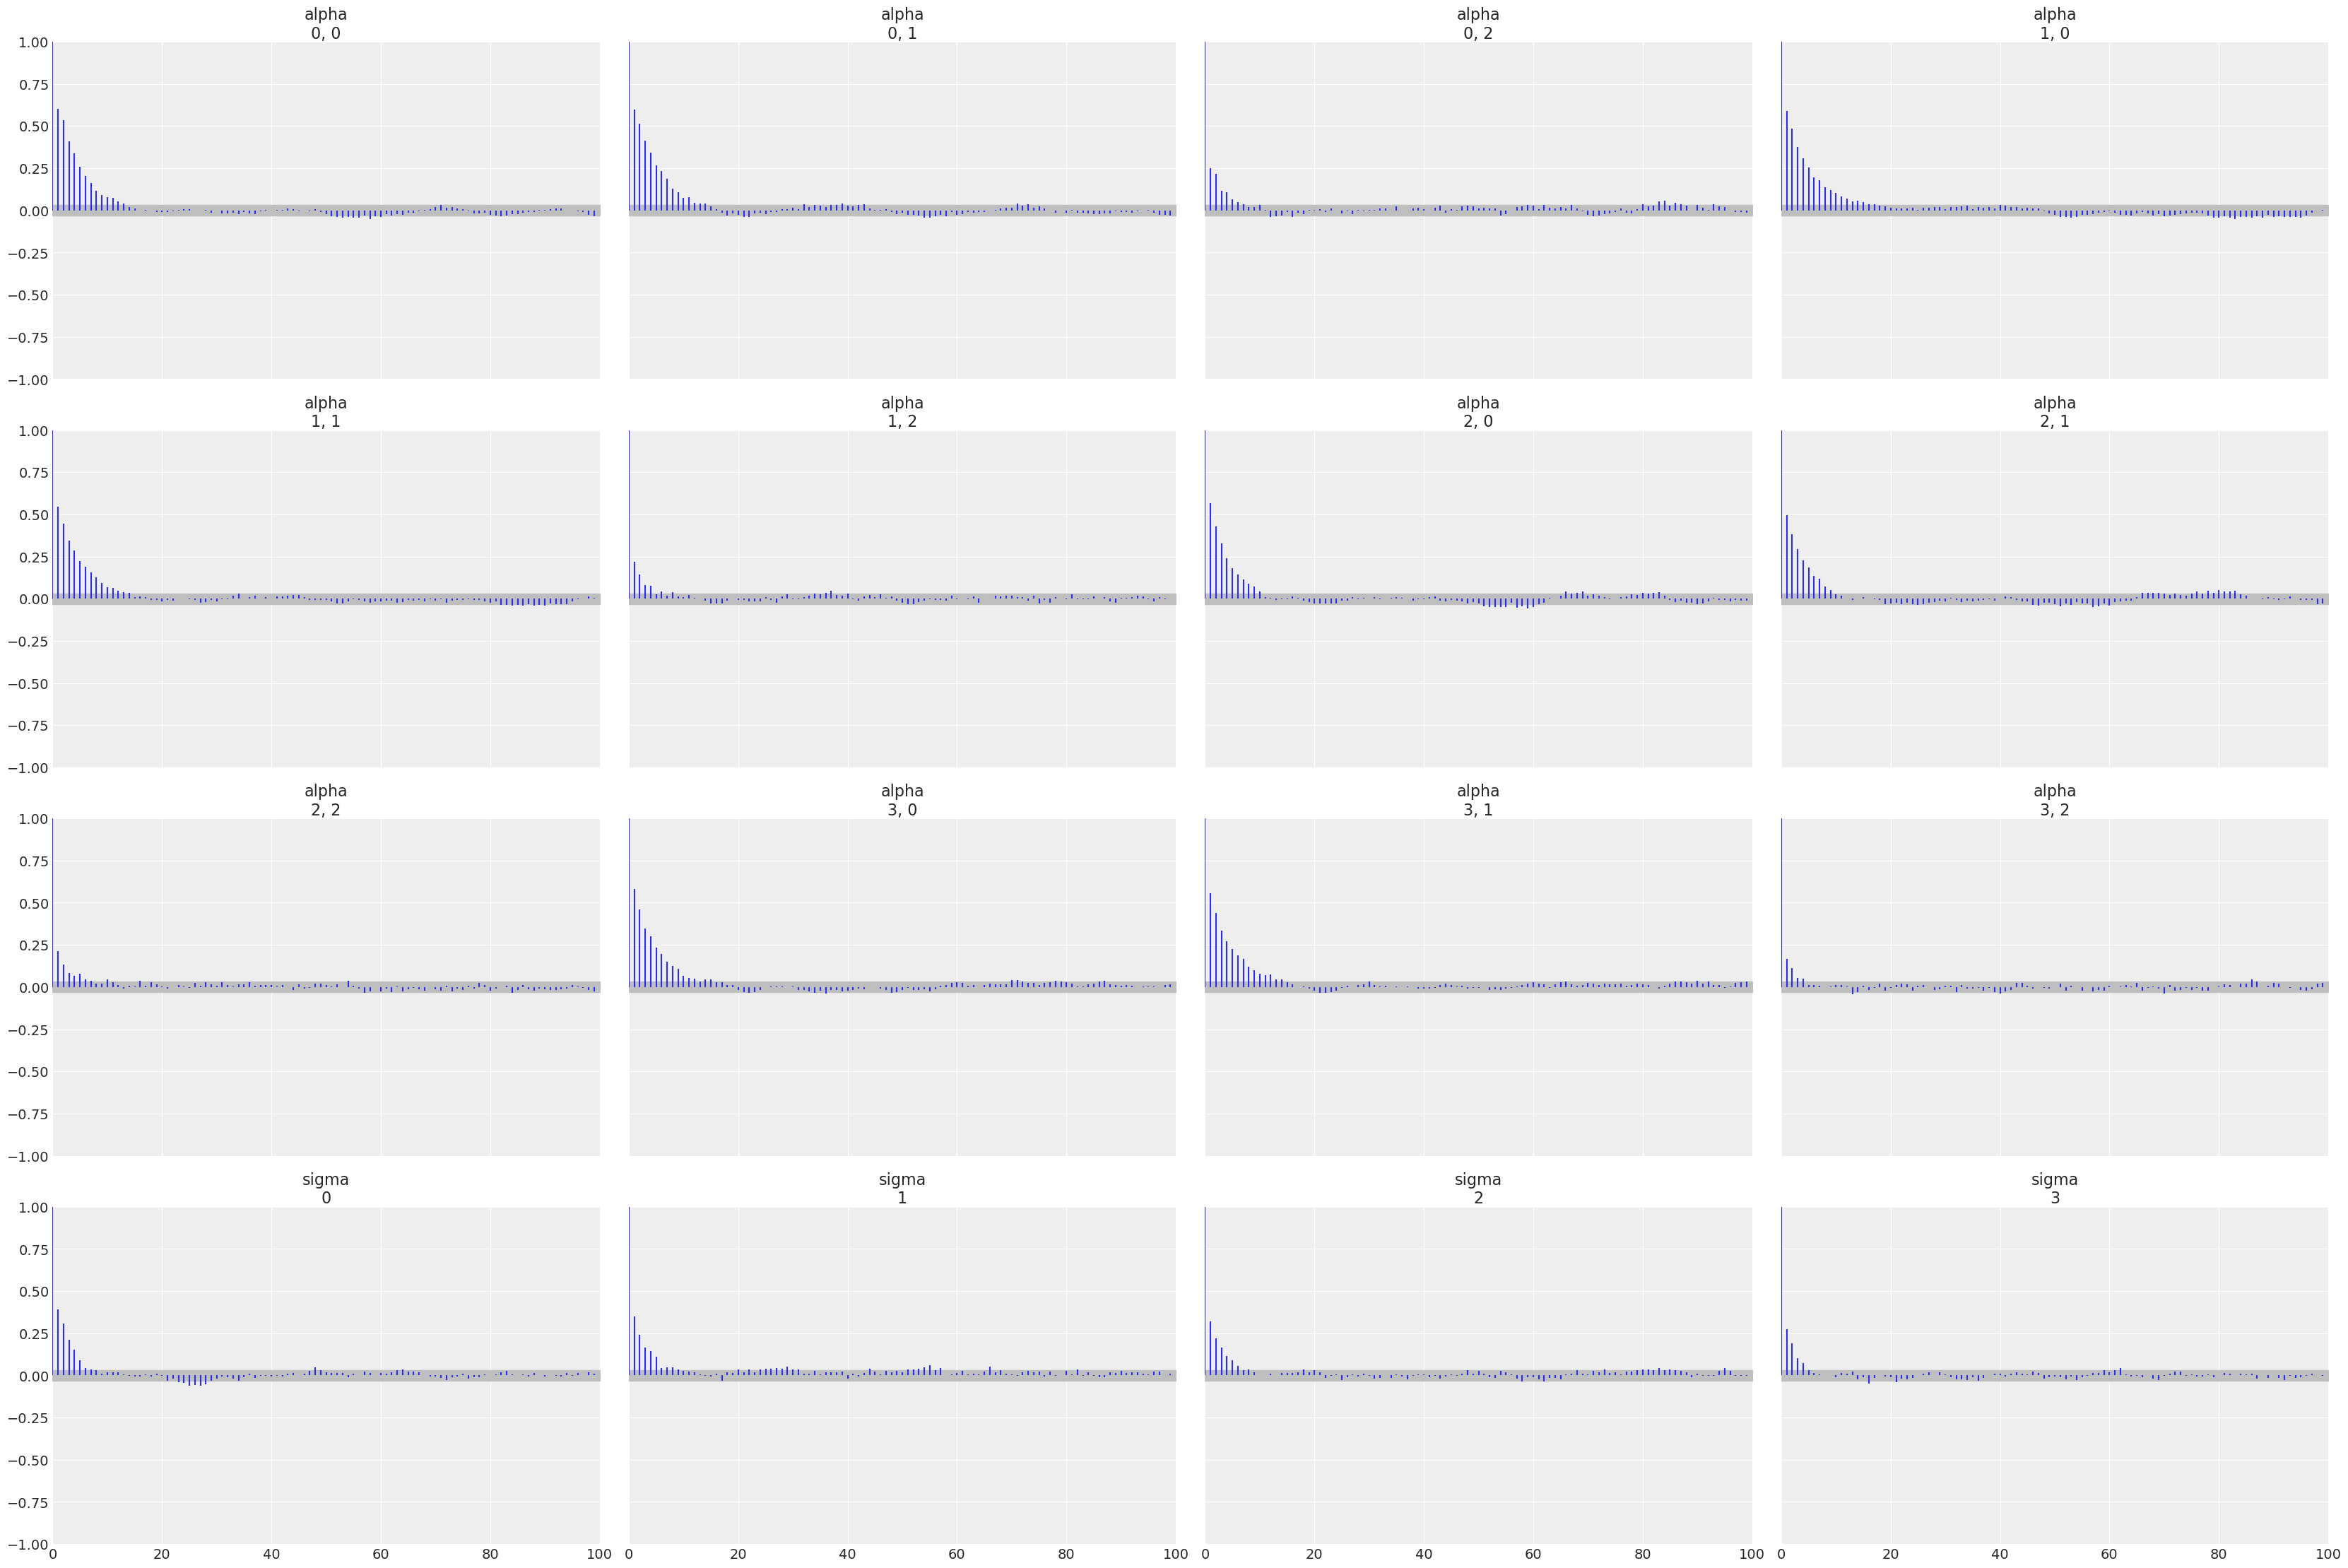

In [27]:
az.plot_autocorr(trace_model_1, var_names=["alpha","sigma"], max_lag=100) 
plt.show()

Monte Carlo Error

In [28]:
summary_model_1 = az.summary(trace_model_1, var_names=["alpha", "sigma"])
print(summary_model_1[["mean", "sd", "ess_bulk", "mcse_mean"]])

           mean     sd  ess_bulk  mcse_mean
alpha[0]  0.201  0.144    2286.0      0.003
alpha[1]  0.516  0.153    2572.0      0.003
alpha[2]  0.284  0.101    6768.0      0.001
sigma     0.522  0.071    4987.0      0.001


In [29]:
# summry all the coefficients in a single dataframe
coeff_summary_model_1 = az.summary(trace_model_1, var_names=coefficients)
print(coeff_summary_model_1)

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov -0.35  0.777  -1.838    1.074       0.01    0.006    6530.0   

          ess_tail  r_hat  
beta_pov    8352.0    1.0  


In [30]:
az.summary(trace_model_1, var_names=["alpha","sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],0.201,0.144,0.000,0.457,0.003,0.002,2286.0,4003.0,1.0
alpha[1],0.516,0.153,0.241,0.804,0.003,0.001,2572.0,5413.0,1.0
alpha[2],0.284,0.101,0.094,0.471,0.001,0.001,6768.0,10667.0,1.0
sigma,0.522,0.071,0.395,0.657,0.001,0.001,4987.0,9293.0,1.0


Model metrics WAIC and LOO

In [31]:
loo_result_model_1 = az.loo(trace_model_1)
print(loo_result_model_1)

Computed from 16000 posterior samples and 53 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -143.23     6.90
p_loo       23.26        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       40   75.5%
   (0.70, 1]   (bad)        11   20.8%
   (1, Inf)   (very bad)    2    3.8%



/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [32]:
waic_result_model_1 = az.waic(trace_model_1)
print(waic_result_model_1)

Computed from 16000 posterior samples and 53 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -137.26     6.00
p_waic       17.29        -

There has been a warning during the calculation. Please check the results.


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


####  II BYM-T model 2: D(5,2,1)

In [33]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_2:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   # Penalizes complexity: Favors Noise > ICAR > TDA
   # Example: 10x more pressure to stay "Noisy" than "Topological"
   alpha = pm.Dirichlet("alpha", a=np.array([5.0, 2.0, 1.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

In [34]:
with model_2:

    # # Sample from the model:
    trace_model_2 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 155 seconds.


In [35]:
# Calculate r_hat for sigma and phi
rhat_data_model_2 = az.rhat(trace_model_2, var_names=["sigma","alpha","beta_pov"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_2["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_2["alpha"].values}')

R-hat for sigma: 1.000207978029442
R-hat for alpha: [1.00033964 1.00051715 1.00022855]


In [36]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_2[var].values}')

R-hat for beta_pov: 1.000047466236938


In [37]:
# summry all the coefficients in a single dataframe
coeff_summary_model_2 = az.summary(trace_model_2, var_names=coefficients)
print(coeff_summary_model_2)

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov -0.219  0.802  -1.761     1.29      0.007    0.006   11660.0   

          ess_tail  r_hat  
beta_pov   10631.0    1.0  


In [38]:
az.summary(trace_model_2, var_names=["sigma","alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.511,0.069,0.385,0.640,0.001,0.000,8944.0,11681.0,1.0
alpha[0],0.446,0.140,0.189,0.704,0.002,0.001,7114.0,9122.0,1.0
alpha[1],0.347,0.127,0.116,0.584,0.002,0.001,6348.0,7655.0,1.0
alpha[2],0.208,0.093,0.041,0.380,0.001,0.001,12060.0,10911.0,1.0


####  III. I. BYM-T model 3: D(2,2,1)

In [39]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_3:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   # Penalizes complexity: Favors Noise > ICAR > TDA
   # Biased towards finding the Topological effect
   alpha = pm.Dirichlet("alpha", a=np.array([2.0, 2.0, 1.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

In [40]:
with model_3:

    # # Sample from the model:
    trace_model_3 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 140 seconds.


In [41]:
# Calculate r_hat for sigma and phi
rhat_data_model_3 = az.rhat(trace_model_3, var_names=["sigma","alpha","beta_pov"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_3["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_3["alpha"].values}')

R-hat for sigma: 1.0014114806691223
R-hat for alpha: [1.00054326 1.00049429 1.00007963]


In [42]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_3[var].values}')

R-hat for beta_pov: 1.0001478250550955


In [43]:
# summary all the coefficients in a single dataframe
coeff_summary_model_3 = az.summary(trace_model_3, var_names=coefficients)
print(coeff_summary_model_3)

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov -0.312  0.798  -1.754    1.261      0.008    0.007    8852.0   

          ess_tail  r_hat  
beta_pov   10311.0    1.0  


In [44]:
az.summary(trace_model_3, var_names=["sigma","alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.519,0.070,0.393,0.655,0.001,0.001,6984.0,10249.0,1.0
alpha[0],0.260,0.139,0.024,0.508,0.002,0.001,4154.0,7025.0,1.0
alpha[1],0.487,0.142,0.234,0.766,0.002,0.001,4609.0,6715.0,1.0
alpha[2],0.254,0.098,0.075,0.437,0.001,0.001,10363.0,11165.0,1.0


####  IV. I. BYM-T model 3: D(1,1,4)

In [45]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_4:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   # Penalizes complexity: Favors Noise > ICAR > TDA
   # Biased towards finding the Topological effect
   alpha = pm.Dirichlet("alpha", a=np.array([1.0, 1.0, 4.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

In [46]:
with model_4:

    # # Sample from the model:
    trace_model_4 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 136 seconds.


In [47]:
# Calculate r_hat for sigma and phi
rhat_data_model_4 = az.rhat(trace_model_4, var_names=["sigma","alpha","beta_pov"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_4["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_4["alpha"].values}')

R-hat for sigma: 1.0013988053103176
R-hat for alpha: [1.00057165 1.00027674 1.00029981]


In [48]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_4[var].values}')

R-hat for beta_pov: 1.0003559375515636


In [49]:
# summary all the coefficients in a single dataframe
coeff_summary_model_4 = az.summary(trace_model_4, var_names=coefficients)
print(coeff_summary_model_4)

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov -0.471  0.753  -1.895    0.948       0.01    0.006    5836.0   

          ess_tail  r_hat  
beta_pov    8237.0    1.0  


In [50]:
az.summary(trace_model_4, var_names=["sigma","alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.517,0.067,0.400,0.650,0.001,0.001,5097.0,8917.0,1.0
alpha[0],0.164,0.121,0.000,0.380,0.002,0.001,2421.0,4111.0,1.0
alpha[1],0.457,0.133,0.201,0.696,0.002,0.001,2871.0,4677.0,1.0
alpha[2],0.379,0.092,0.209,0.552,0.001,0.001,7674.0,10495.0,1.0


Compare model results

In [51]:
import pandas as pd
import arviz as az

# 1. Organize your traces
models_dict = {
    "D(1,1,1)": trace_model_1,
    "D(5,2,1)": trace_model_2,
    "D(2,2,1)": trace_model_3,
    "D(1,1,4)": trace_model_4
}

all_summaries = []

for name, trace in models_dict.items():
    # Get stats summary
    summary = az.summary(trace, var_names=["intercept","alpha", "sigma"], kind="stats")
    
    # Select only the 'mean' column and rename it to the Model Name
    model_mean = summary[['mean']].rename(columns={'mean': name})
    
    all_summaries.append(model_mean)

# 2. Join all columns together
comparison_table = pd.concat(all_summaries, axis=1)

# 3. Rename the index for better readability
new_index = {
    "intercept": "Intercept (Baseline)",  # --- CHANGE HERE: Add label for intercept ---
    "alpha[0]": "Alpha_Noise (IID)",
    "alpha[1]": "Alpha_Spatial (ICAR)",
    "alpha[2]": "Alpha_TDA (Topological)",
    "sigma": "Sigma (Total Variance)"
}
comparison_table.index = [new_index.get(i, i) for i in comparison_table.index]

# 4. (Optional) Add a "Prior Weight" row to see the starting assumption
# This helps see how much the data 'pulled' the result away from the prior
# comparison_table.loc['Prior TDA Weight'] = [0.33, 0.125, 0.20, 0.66]

print("--- Parameter Comparison Across Models ---")
print(comparison_table.round(4))

# To save as CSV for Excel/LaTeX:
# comparison_table.to_csv("model_comparison_table.csv")

--- Parameter Comparison Across Models ---
                         D(1,1,1)  D(5,2,1)  D(2,2,1)  D(1,1,4)
Intercept (Baseline)       -1.051    -1.079    -1.060    -1.026
Alpha_Noise (IID)           0.201     0.446     0.260     0.164
Alpha_Spatial (ICAR)        0.516     0.347     0.487     0.457
Alpha_TDA (Topological)     0.284     0.208     0.254     0.379
Sigma (Total Variance)      0.522     0.511     0.519     0.517


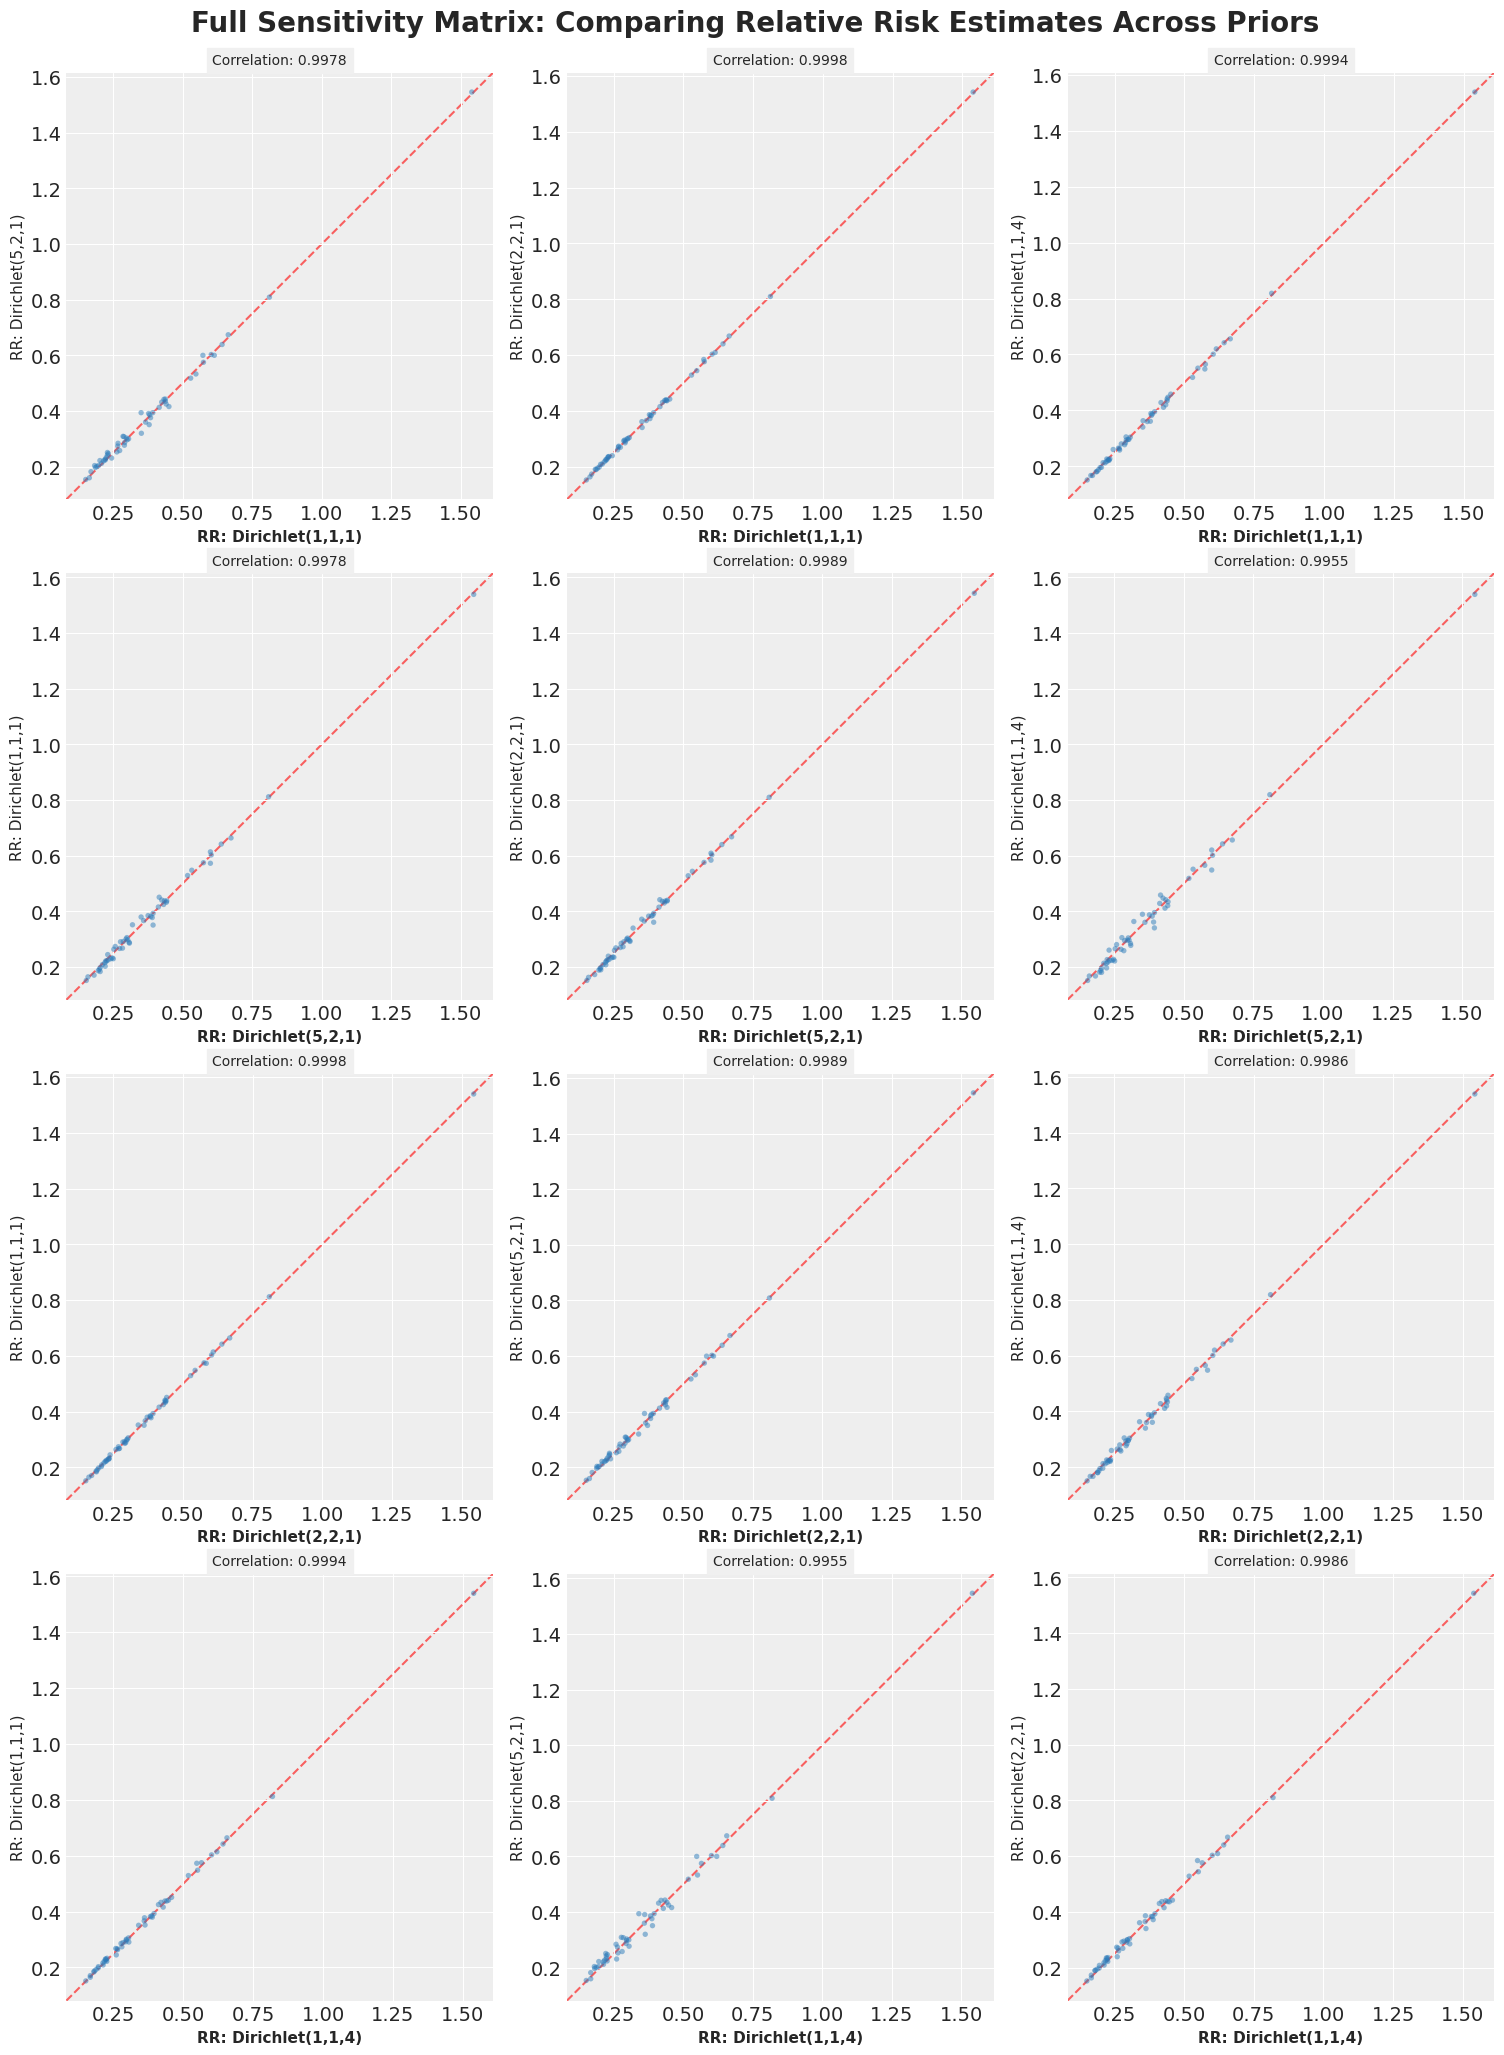

In [52]:
# --- STEP 1: PREPARE DATA ---
# (Assuming you have your traces in this dictionary)
models_dict = {
    "Dirichlet(1,1,1)": trace_model_1,
    "Dirichlet(5,2,1)": trace_model_2,
    "Dirichlet(2,2,1)": trace_model_3,
    "Dirichlet(1,1,4)": trace_model_4
}

# Extract RR (Relative Risk) means into a DataFrame
# IMPORTANT: Ensure your model saved the risk as "RR", "mu", or "theta". 
# If it's log-risk ("eta"), use np.exp(summary['mean'])
var_name = "rr" 

rr_data = {}
for name, trace in models_dict.items():
    summary = az.summary(trace, var_names=[var_name], kind="stats")
    rr_data[name] = summary["mean"].values

df_rr = pd.DataFrame(rr_data)

# --- STEP 2: GENERATE THE 4x3 GRID ---

# We use ALL 4 models as potential X-axes
x_models = list(models_dict.keys()) 

# Create 4 rows (one for each X-model) and 3 columns (comparisons)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20), constrained_layout=True)

for i, x_model in enumerate(x_models):
    # Find the other 3 models to compare against
    y_models = [m for m in x_models if m != x_model]
    
    for j, y_model in enumerate(y_models):
        ax = axes[i, j]
        
        # 1. Scatter Plot
        # using alpha helps visualize overlapping points
        ax.scatter(df_rr[x_model], df_rr[y_model], alpha=0.5, s=15, c='#2b7bba', edgecolors='none')
        
        # 2. Add Red Diagonal Line (Identity Line: y=x)
        # This shows where models agree perfectly
        low = min(ax.get_xlim()[0], ax.get_ylim()[0])
        high = max(ax.get_xlim()[1], ax.get_ylim()[1])
        ax.plot([low, high], [low, high], 'r--', alpha=0.6, linewidth=1.5, zorder=0)
        
        # 3. Calculate Correlation
        corr = df_rr[x_model].corr(df_rr[y_model])
        
        # 4. Labels and Styling
        ax.set_xlabel(f"RR: {x_model}", fontsize=11, fontweight='bold')
        ax.set_ylabel(f"RR: {y_model}", fontsize=11)
        ax.set_title(f"Correlation: {corr:.4f}", fontsize=10, backgroundcolor='#f0f0f0')
        
        # Force square aspect ratio so the diagonal is truly 45 degrees
        ax.set_aspect('equal')
        # Standardize limits for this specific plot
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

# Main Title
fig.suptitle("Full Sensitivity Matrix: Comparing Relative Risk Estimates Across Priors", 
             fontsize=20, fontweight='bold', y=1.02)

# Save high-quality version for paper
# plt.savefig("sensitivity_matrix_12plots.png", dpi=300, bbox_inches='tight')

plt.show()

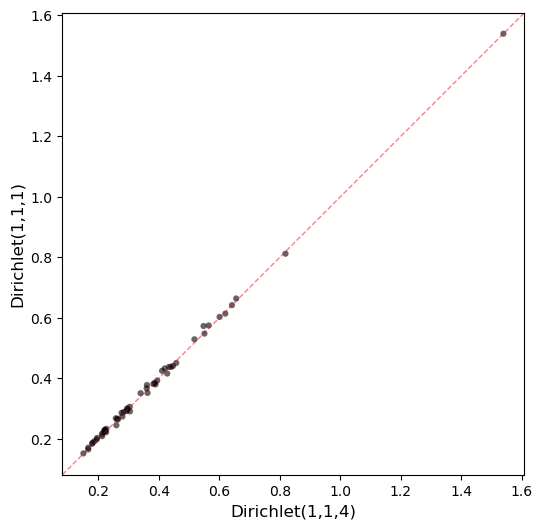

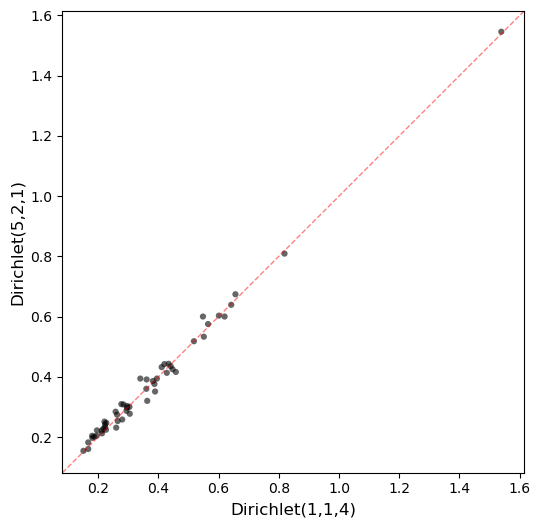

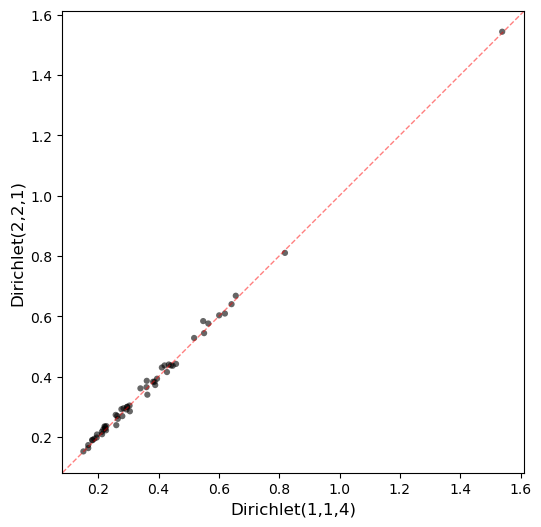

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import arviz as az

# --- FIX 1: Reset global styles to avoid hidden themes ---
plt.style.use('default') 

# ... [Your Data Preparation Code remains the same] ...
# (Assuming df_rr is ready)

# The model to keep on the X-axis
x_model = "Dirichlet(1,1,4)"
y_models = ["Dirichlet(1,1,1)", "Dirichlet(5,2,1)", "Dirichlet(2,2,1)"]

# --- GENERATE PLOTS ---

for y_model in y_models:
    # --- FIX 2: Set 'facecolor' in subplots for the OUTER frame ---
    fig, ax = plt.subplots(figsize=(6, 6), facecolor='white')
    
    # --- FIX 3: Explicitly set the INNER plot area to white ---
    ax.set_facecolor('white')

    # 1. Plain Scatter Plot
    ax.scatter(df_rr[x_model], df_rr[y_model], 
               alpha=0.6, s=20, c='black', edgecolors='none')
    
    # 2. Identity Line
    data_min = min(df_rr[x_model].min(), df_rr[y_model].min())
    data_max = max(df_rr[x_model].max(), df_rr[y_model].max())
    pad = (data_max - data_min) * 0.05
    low, high = data_min - pad, data_max + pad
    
    ax.plot([low, high], [low, high], 'r--', linewidth=1, alpha=0.5, label='Identity Line')
    
    # 3. Styling
    ax.set_xlabel(f"{x_model}", fontsize=12)
    ax.set_ylabel(f"{y_model}", fontsize=12)
    
    ax.set_aspect('equal')
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    
    # Also ensure grids don't appear if they were on by default
    ax.grid(False) 

    plt.show()